In [12]:
import numpy as np
import pandas as pd
from collections import defaultdict

In [13]:
wd = "/data/ross/assay_calibration"
data_dir = f"{wd}/predictor_scores/single_gene_calibration_data"

sg_calibration_genes = ["BRCA1","BRCA2", "F9","JAG1","MSH2","SCN5A","TP53","TSC2"]

predictors = ("REVEL", "MP2", "AM")


def read_labeled_f(path):
    return pd.read_csv(
        path,
        sep='\t',
        header=None,
        names=["variant_id", "protein_variant", "score", "is_pathogenic"]
    )

def read_unlabeled_f(path):
    return pd.read_csv(
        path,
        sep='\t',
        header=None,
        names=["variant_id", "codon", "protein_variant", "score"]
    )


def process_gene_predictor(df_clinvar, df_gnomad):
    # Assign sample labels
    # is_pathogenic == 1 → label 0
    # is_pathogenic == 0 → label 1
    df_clinvar["sample_label"] = df_clinvar["is_pathogenic"].map({1: 0, 0: 1})

    # Unlabeled → label 2
    df_gnomad["sample_label"] = 2

    # Keep only needed columns
    df_clinvar_sub = df_clinvar[["protein_variant", "score", "sample_label"]]
    df_gnomad_sub = df_gnomad[["protein_variant", "score", "sample_label"]]

    # Stack (do not drop anything)
    df_all = pd.concat([df_clinvar_sub, df_gnomad_sub], ignore_index=True)

    # Aggregate
    result = (
        df_all
        .groupby("protein_variant", as_index=False)
        .agg({
            "score": "first",  # assumes score is consistent per variant
            "sample_label": lambda x: ",".join(sorted(set(map(str, x))))
        })
        .rename(columns={"sample_label": "sample_assignments"})
    )

    return result

gene_predictor_dfs = defaultdict(dict)
for gene in sg_calibration_genes:
    for predictor in predictors:
        clinvar_f = f"{data_dir}/{gene}/{gene}_{predictor}_labeled.txt"
        gnomad_f = f"{data_dir}/{gene}/{gene}_{predictor}_unlabeled.txt"

        df_clinvar = read_labeled_f(clinvar_f)
        df_gnomad = read_unlabeled_f(gnomad_f)

        gene_predictor_dfs[gene][predictor] = process_gene_predictor(df_clinvar, df_gnomad)

(array([ 8., 24., 65., 49., 61., 45., 43., 34., 57., 78.]),
 array([0.104 , 0.1917, 0.2794, 0.3671, 0.4548, 0.5425, 0.6302, 0.7179,
        0.8056, 0.8933, 0.981 ]),
 <BarContainer object of 10 artists>)

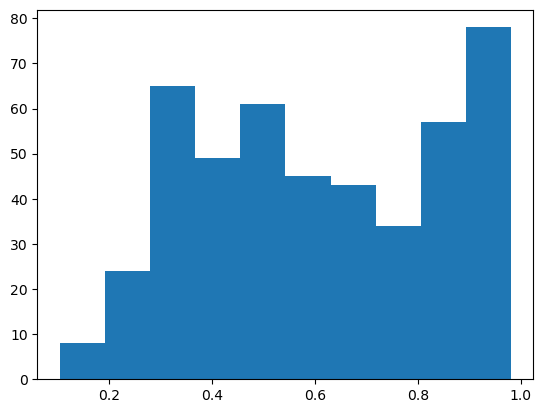

In [19]:
temp_df = gene_predictor_dfs["TP53"]["REVEL"]
plt.hist(temp_df[temp_df.sample_assignments.str.contains("2")].score)

In [53]:
import os

for gene in gene_predictor_dfs:
    gene_dir = f"{data_dir}/{gene}"
    os.makedirs(gene_dir, exist_ok=True)

    for predictor in gene_predictor_dfs[gene]:
        df = gene_predictor_dfs[gene][predictor]

        out_path = f"{gene_dir}/{gene}_{predictor}.csv.gz"
        df.to_csv(out_path, index=False, compression="gzip")

### fit preview for liam

In [54]:
import gzip
import json

file_path = '/data/ross/assay_calibration/replicate_run_datasets_results_1000bootstraps_100fits.json.gz'

with gzip.open(file_path, 'rt', encoding='UTF-8') as zipfile:
    data = json.load(zipfile)

data = data["BRCA1_Findlay_2018"]

In [66]:
raw_bootstraps['0']['2c']

{'dataset_name': 'BRCA1_Findlay_2018',
 'bootstrap_seed': 0,
 'num_components': 2,
 'fit_idx': 24,
 'fit': {'component_params': [[-1.4525522009851162,
    -1.6360832407952826,
    0.7046758363385534],
   [-1.798123253019028, 0.2688148540508043, 0.48150227155636055]],
  'weights': [[0.9830227116245023, 0.01697728837549783],
   [0.004460523982561541, 0.9955394760174384],
   [0.22212840001799833, 0.7778715999820016],
   [0.007449786891920858, 0.9925502131080792]],
  'kmeans': {'type': 'KMeans',
   'n_clusters': 2,
   'cluster_centers': [[-2.125285096998601], [-0.0724485760764545]],
   'labels': [0,
    0,
    0,
    0,
    1,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    1,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0

In [70]:
import gzip
import json

raw_bootstraps = data
output_path = '/data/ross/assay_calibration/brca_findlay_example_fits.json.gz'

shrunk_final = {}

for bootstrap_idx, iteration in raw_bootstraps.items():
    # iteration is a dict like {"2c": {...}, "3c": {...}}
    shrunk_iteration = {}
    
    for model_key, model_data in iteration.items():
        # Access the 'fit' dictionary if it exists
        if model_data is None:
            continue
            
        fit_data = model_data.get("fit", {})
        
        # Keep ONLY params and weights inside the model key
        shrunk_iteration[model_key] = {
            "fit": {
                "component_params": fit_data.get("component_params"),
                "weights": fit_data.get("weights")
            }
        }

    shrunk_final[bootstrap_idx] = shrunk_iteration

with gzip.open(output_path, 'wt', encoding='UTF-8') as f:
    json.dump(shrunk_final, f)


### old testing

In [1]:
import numpy as np
import pandas as pd

In [6]:
wd = "/data/ross/assay_calibration"
df = pd.read_csv(f"{wd}/predictor_scores/variant_aggregated_experimental_predictive_evidence.csv.gz")

In [21]:
df.columns

Index(['gene_symbol', 'protein_variant', '#CHROM', 'POS', 'REF', 'ALT',
       'transcript_id', 'hgvs_c', 'hgvs_p', 'domain',
       'experimental_dataset_highest_evidence', 'assay_score',
       'points_experimental', 'evidence_experimental',
       'points_experimental_clinvar_2018',
       'evidence_experimental_clinvar_2018', 'AlphaMissense_score',
       'points_AlphaMissense_domain_aggregate',
       'evidence_AlphaMissense_domain_aggregate',
       'points_AlphaMissense_single_gene',
       'evidence_AlphaMissense_single_gene', 'MutPred2_score',
       'points_MutPred2_domain_aggregate',
       'evidence_MutPred2_domain_aggregate', 'points_MutPred2_single_gene',
       'evidence_MutPred2_single_gene', 'REVEL_score',
       'points_REVEL_domain_aggregate', 'evidence_REVEL_domain_aggregate',
       'points_REVEL_single_gene', 'evidence_REVEL_single_gene'],
      dtype='object')

In [7]:
df_pp = pd.read_csv(f"{wd}/dataframe/integrated_variant_effect_dataset.tsv.gz",sep='\t')

/tmp/ipykernel_298437/2870372404.py:1: DtypeWarning: Columns (5,12,13,23,24,25,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,52,55,65,66,67,68,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pp = pd.read_csv(f"{wd}/dataframe/integrated_variant_effect_dataset.tsv.gz",sep='\t')


In [17]:
pd.set_option('display.max_columns', None)
df_pp

,Unnamed: 0,ID,Dataset,Gene,HGNC_id,Chrom,STRAND,hg19_pos,hg38_start,hg38_end,ref_allele,alt_allele,auth_transcript_id,transcript_pos,transcript_ref,transcript_alt,aa_pos,aa_ref,aa_alt,hgvs_c,hgvs_p,consequence,simplified_consequence,auth_reported_score,auth_reported_rep_score,auth_reported_func_class,splice_measure,gnomad_MAF,clinvar_sig_2025,clinvar_star_2025,clinvar_date_last_reviewed_2025,nucleotide_or_aa,Ensembl Transcript ID,RefSeq Transcript ID,Interval 1 Name,Interval 1 Range,Interval 1 Class,Interval 2 Name,Interval 2 Range,Interval 2 Class,Interval 3 Name,Interval 3 Range,Interval 3 Class,Interval 4 Name,Interval 4 Range,Interval 4 Class,Interval 5 Name,Interval 5 Range,Interval 5 Class,Interval 6 Name,Interval 6 Range,Interval 6 Class,Flag,REVEL,AM_score,AM_class,spliceAI_DS_AG,spliceAI_DS_AL,spliceAI_DS_DG,spliceAI_DS_DL,spliceAI_DP_AG,spliceAI_DP_AL,spliceAI_DP_DG,spliceAI_DP_DL,MutPred2,MP2_train,REVEL_train,clinvar_sig_2018,clinvar_star_2018,clinvar_date_last_reviewed_2018
0,0,BRCA1_Findlay_2018_var1,BRCA1_Findlay_2018,BRCA1,1100,17,-1.0,41276135.0,43124118.0,43124118.0,T,G,NM_007294.3,-19-3,A,C,NaN,NaN,NaN,c.-19-3A>C,NaN,Splice region,splicing_variant,-0.372611,-0.568675758504309;-0.176545248348852,FUNC,Yes,NaN,Likely benign,"criteria provided, single submitter","Jun 27, 2023",nucleotide,ENST00000357654.9,NM_007294.3,Functional,"[-0.748, Inf)",Normal,Intermediate,"(-1.328, -0.748)",Not specified,Non-functional,"(-Inf,-1.328]",Abnormal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-3.0,-16.0,-14.0,-3.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,BRCA1_Findlay_2018_var2,BRCA1_Findlay_2018,BRCA1,1100,17,-1.0,41276135.0,43124118.0,43124118.0,T,C,NM_007294.3,-19-3,A,G,NaN,NaN,NaN,c.-19-3A>G,NaN,Splice region,splicing_variant,-0.045313,-0.332667114078832;0.242040175629815,FUNC,Yes,0.000030,Benign,reviewed by expert panel,"Jun 18, 2019",nucleotide,ENST00000357654.9,NM_007294.3,Functional,"[-0.748, Inf)",Normal,Intermediate,"(-1.328, -0.748)",Not specified,Non-functional,"(-Inf,-1.328]",Abnormal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9551,0.8198,0.0001,0.0000,-1.0,-3.0,-1.0,-16.0,NaN,NaN,NaN,Conflicting interpretations of pathogenicity,"criteria provided, conflicting interpretations","Sep 13, 2016"
2,2,BRCA1_Findlay_2018_var3,BRCA1_Findlay_2018,BRCA1,1100,17,-1.0,41276135.0,43124118.0,43124118.0,T,A,NM_007294.3,-19-3,A,T,NaN,NaN,NaN,c.-19-3A>T,NaN,Splice region,splicing_variant,-0.108254,-0.440230467981572;0.223722191334123,FUNC,Yes,NaN,not provided,no classification provided,-,nucleotide,ENST00000357654.9,NM_007294.3,Functional,"[-0.748, Inf)",Normal,Intermediate,"(-1.328, -0.748)",Not specified,Non-functional,"(-Inf,-1.328]",Abnormal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-3.0,-16.0,-43.0,-3.0,NaN,NaN,NaN,NaN,NaN,NaN
3,3,BRCA1_Findlay_2018_var4,BRCA1_Findlay_2018,BRCA1,1100,17,-1.0,41276134.0,43124117.0,43124117.0,T,G,NM_007294.3,-19-2,A,C,NaN,NaN,NaN,c.-19-2A>C,NaN,Canonical splice,splice_site_variant,-0.277963,-0.41057727764695;-0.145348986773218,FUNC,Yes,NaN,not provided,no classification provided,-,nucleotide,ENST00000357654.9,NM_007294.3,Functional,"[-0.748, Inf)",Normal,Intermediate,"(-1.328, -0.748)",Not specified,Non-functional,"(-Inf,-1.328]",Abnormal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8487,0.9086,0.0001,0.0000,-15.0,-2.0,-19.0,-50.0,NaN,NaN,NaN,NaN,NaN,NaN
4,4,BRCA1_Findlay_2018_var5,BRCA1_Findlay_2018,BRCA1,1100,17,-1.0,41276134.0,43124117.0,43124117.0,T,C,NM_007294.3,-19-2,A,G,NaN,NaN,NaN,c.-19-2A>G,NaN,Canonical splice,splice_site_variant,-0.388414,-0.6350191556350679;-0.141808664620659,FUNC,Yes,NaN,Pathogenic,"criteria provided, single submitter","Oct 02, 2015",nucleotide,ENST00000357654.9,NM_007294.3,Functional,"[-0.748, Inf)",Normal,Intermediate,"(-1.328, -0.748)",Not specified,Non-functional,"(-Inf,-1.328]",Abnormal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9921,0.9089,0.0001,0.0000,-1.0,-2.0,0.0,

In [15]:
df_pp.Chrom.unique()

array([17, 13, 3, 20, 2, 16, 7, 1, '3', 'X', '17', 19, 22, 14, 21, '19',
       '7', 11, 8, '8', '11', 10, 4], dtype=object)

In [22]:
import pandas as pd

columns_to_add = [
    'AlphaMissense_score',
    'points_AlphaMissense_domain_aggregate',
    'evidence_AlphaMissense_domain_aggregate',
    'points_AlphaMissense_single_gene',
    'evidence_AlphaMissense_single_gene',
    'MutPred2_score',
    'points_MutPred2_domain_aggregate',
    'evidence_MutPred2_domain_aggregate',
    'points_MutPred2_single_gene',
    'evidence_MutPred2_single_gene',
    'REVEL_score',
    'points_REVEL_domain_aggregate',
    'evidence_REVEL_domain_aggregate',
    'points_REVEL_single_gene',
    'evidence_REVEL_single_gene'
]

# --- build merge keys in df ---
df_prepped = df.copy()

df_prepped["Chrom"] = df_prepped["#CHROM"].astype(str).str.replace("chr", "", regex=False)

# optional safety: ensure consistent dtypes
df_prepped["POS"] = df_prepped["POS"].astype(df_pp["hg38_start"].dtype)

# --- select only needed columns from df ---
df_subset = df_prepped[
    ["gene_symbol", "Chrom", "POS", "REF", "ALT"] + columns_to_add
].copy()

# --- perform merge ---
df_with_predictor_calibrations = df_pp.merge(
    df_subset,
    how="left",
    left_on=["Gene", "Chrom", "hg38_start", "ref_allele", "alt_allele"],
    right_on=["gene_symbol", "Chrom", "POS", "REF", "ALT"],
)

# --- cleanup redundant key columns from df side ---
df_with_predictor_calibrations = df_with_predictor_calibrations.drop(
    columns=["gene_symbol", "POS", "REF", "ALT"]
)

In [23]:
df_with_predictor_calibrations

,Unnamed: 0,ID,Dataset,Gene,HGNC_id,Chrom,STRAND,hg19_pos,hg38_start,hg38_end,ref_allele,alt_allele,auth_transcript_id,transcript_pos,transcript_ref,transcript_alt,aa_pos,aa_ref,aa_alt,hgvs_c,hgvs_p,consequence,simplified_consequence,auth_reported_score,auth_reported_rep_score,auth_reported_func_class,splice_measure,gnomad_MAF,clinvar_sig_2025,clinvar_star_2025,clinvar_date_last_reviewed_2025,nucleotide_or_aa,Ensembl Transcript ID,RefSeq Transcript ID,Interval 1 Name,Interval 1 Range,Interval 1 Class,Interval 2 Name,Interval 2 Range,Interval 2 Class,Interval 3 Name,Interval 3 Range,Interval 3 Class,Interval 4 Name,Interval 4 Range,Interval 4 Class,Interval 5 Name,Interval 5 Range,Interval 5 Class,Interval 6 Name,Interval 6 Range,Interval 6 Class,Flag,REVEL,AM_score,AM_class,spliceAI_DS_AG,spliceAI_DS_AL,spliceAI_DS_DG,spliceAI_DS_DL,spliceAI_DP_AG,spliceAI_DP_AL,spliceAI_DP_DG,spliceAI_DP_DL,MutPred2,MP2_train,REVEL_train,clinvar_sig_2018,clinvar_star_2018,clinvar_date_last_reviewed_2018,AlphaMissense_score,points_AlphaMissense_domain_aggregate,evidence_AlphaMissense_domain_aggregate,points_AlphaMissense_single_gene,evidence_AlphaMissense_single_gene,MutPred2_score,points_MutPred2_domain_aggregate,evidence_MutPred2_domain_aggregate,points_MutPred2_single_gene,evidence_MutPred2_single_gene,REVEL_score,points_REVEL_domain_aggregate,evidence_REVEL_domain_aggregate,points_REVEL_single_gene,evidence_REVEL_single_gene
0,0,BRCA1_Findlay_2018_var1,BRCA1_Findlay_2018,BRCA1,1100,17,-1.0,41276135.0,43124118.0,43124118.0,T,G,NM_007294.3,-19-3,A,C,NaN,NaN,NaN,c.-19-3A>C,NaN,Splice region,splicing_variant,-0.372611,-0.568675758504309;-0.176545248348852,FUNC,Yes,NaN,Likely benign,"criteria provided, single submitter","Jun 27, 2023",nucleotide,ENST00000357654.9,NM_007294.3,Functional,"[-0.748, Inf)",Normal,Intermediate,"(-1.328, -0.748)",Not specified,Non-functional,"(-Inf,-1.328]",Abnormal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-3.0,-16.0,-14.0,-3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,BRCA1_Findlay_2018_var2,BRCA1_Findlay_2018,BRCA1,1100,17,-1.0,41276135.0,43124118.0,43124118.0,T,C,NM_007294.3,-19-3,A,G,NaN,NaN,NaN,c.-19-3A>G,NaN,Splice region,splicing_variant,-0.045313,-0.332667114078832;0.242040175629815,FUNC,Yes,0.000030,Benign,reviewed by expert panel,"Jun 18, 2019",nucleotide,ENST00000357654.9,NM_007294.3,Functional,"[-0.748, Inf)",Normal,Intermediate,"(-1.328, -0.748)",Not specified,Non-functional,"(-Inf,-1.328]",Abnormal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9551,0.8198,0.0001,0.0000,-1.0,-3.0,-1.0,-16.0,NaN,NaN,NaN,Conflicting interpretations of pathogenicity,"criteria provided, conflicting interpretations","Sep 13, 2016",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,BRCA1_Findlay_2018_var3,BRCA1_Findlay_2018,BRCA1,1100,17,-1.0,41276135.0,43124118.0,43124118.0,T,A,NM_007294.3,-19-3,A,T,NaN,NaN,NaN,c.-19-3A>T,NaN,Splice region,splicing_variant,-0.108254,-0.440230467981572;0.223722191334123,FUNC,Yes,NaN,not provided,no classification provided,-,nucleotide,ENST00000357654.9,NM_007294.3,Functional,"[-0.748, Inf)",Normal,Intermediate,"(-1.328, -0.748)",Not specified,Non-functional,"(-Inf,-1.328]",Abnormal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-3.0,-16.0,-43.0,-3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,BRCA1_Findlay_2018_var4,BRCA1_Findlay_2018,BRCA1,1100,17,-1.0,41276134.0,43124117.0,43124117.0,T,G,NM_007294.3,-19-2,A,C,NaN,NaN,NaN,c.-19-2A>C,NaN,Canonical splice,splice_site_variant,-0.277963,-0.41057727764695;-0.145348986773218,FUNC,Yes,NaN,not provided,no classification provided,-,nucleotide,ENST00000357654.9,NM_007294.3,Functional,"[-0.748, Inf)",Normal,Intermediate,"(-1.328, -0.748)",Not specified,Non-functional,"(-Inf,-1.328]",Abnormal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8487,0.9086,0.0001,0.0000,-15.

In [27]:
df_with_predictor_calibrations["AM_score"].isna().sum()

905667

In [ ]:
df_with_predictor_calibrations.to_csv(f"{wd}/dataframe/integrated_variant_effect_dataset_with_predictor_calibrations.tsv.gz",
                                      sep='\t', compression='gzip', index=False)


In [28]:
df_with_predictor_calibrations[df_with_predictor_calibrations.Gene == "BRCA1"]

,Unnamed: 0,ID,Dataset,Gene,HGNC_id,Chrom,STRAND,hg19_pos,hg38_start,hg38_end,ref_allele,alt_allele,auth_transcript_id,transcript_pos,transcript_ref,transcript_alt,aa_pos,aa_ref,aa_alt,hgvs_c,hgvs_p,consequence,simplified_consequence,auth_reported_score,auth_reported_rep_score,auth_reported_func_class,splice_measure,gnomad_MAF,clinvar_sig_2025,clinvar_star_2025,clinvar_date_last_reviewed_2025,nucleotide_or_aa,Ensembl Transcript ID,RefSeq Transcript ID,Interval 1 Name,Interval 1 Range,Interval 1 Class,Interval 2 Name,Interval 2 Range,Interval 2 Class,Interval 3 Name,Interval 3 Range,Interval 3 Class,Interval 4 Name,Interval 4 Range,Interval 4 Class,Interval 5 Name,Interval 5 Range,Interval 5 Class,Interval 6 Name,Interval 6 Range,Interval 6 Class,Flag,REVEL,AM_score,AM_class,spliceAI_DS_AG,spliceAI_DS_AL,spliceAI_DS_DG,spliceAI_DS_DL,spliceAI_DP_AG,spliceAI_DP_AL,spliceAI_DP_DG,spliceAI_DP_DL,MutPred2,MP2_train,REVEL_train,clinvar_sig_2018,clinvar_star_2018,clinvar_date_last_reviewed_2018,AlphaMissense_score,points_AlphaMissense_domain_aggregate,evidence_AlphaMissense_domain_aggregate,points_AlphaMissense_single_gene,evidence_AlphaMissense_single_gene,MutPred2_score,points_MutPred2_domain_aggregate,evidence_MutPred2_domain_aggregate,points_MutPred2_single_gene,evidence_MutPred2_single_gene,REVEL_score,points_REVEL_domain_aggregate,evidence_REVEL_domain_aggregate,points_REVEL_single_gene,evidence_REVEL_single_gene
0,0,BRCA1_Findlay_2018_var1,BRCA1_Findlay_2018,BRCA1,1100,17,-1.0,41276135.0,43124118.0,43124118.0,T,G,NM_007294.3,-19-3,A,C,NaN,NaN,NaN,c.-19-3A>C,NaN,Splice region,splicing_variant,-0.372611,-0.568675758504309;-0.176545248348852,FUNC,Yes,NaN,Likely benign,"criteria provided, single submitter","Jun 27, 2023",nucleotide,ENST00000357654.9,NM_007294.3,Functional,"[-0.748, Inf)",Normal,Intermediate,"(-1.328, -0.748)",Not specified,Non-functional,"(-Inf,-1.328]",Abnormal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0,-3.0,-16.0,-14.0,-3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,BRCA1_Findlay_2018_var2,BRCA1_Findlay_2018,BRCA1,1100,17,-1.0,41276135.0,43124118.0,43124118.0,T,C,NM_007294.3,-19-3,A,G,NaN,NaN,NaN,c.-19-3A>G,NaN,Splice region,splicing_variant,-0.045313,-0.332667114078832;0.242040175629815,FUNC,Yes,0.00003,Benign,reviewed by expert panel,"Jun 18, 2019",nucleotide,ENST00000357654.9,NM_007294.3,Functional,"[-0.748, Inf)",Normal,Intermediate,"(-1.328, -0.748)",Not specified,Non-functional,"(-Inf,-1.328]",Abnormal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9551,0.8198,0.0001,0.0,-1.0,-3.0,-1.0,-16.0,NaN,NaN,NaN,Conflicting interpretations of pathogenicity,"criteria provided, conflicting interpretations","Sep 13, 2016",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,BRCA1_Findlay_2018_var3,BRCA1_Findlay_2018,BRCA1,1100,17,-1.0,41276135.0,43124118.0,43124118.0,T,A,NM_007294.3,-19-3,A,T,NaN,NaN,NaN,c.-19-3A>T,NaN,Splice region,splicing_variant,-0.108254,-0.440230467981572;0.223722191334123,FUNC,Yes,NaN,not provided,no classification provided,-,nucleotide,ENST00000357654.9,NM_007294.3,Functional,"[-0.748, Inf)",Normal,Intermediate,"(-1.328, -0.748)",Not specified,Non-functional,"(-Inf,-1.328]",Abnormal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0,-3.0,-16.0,-43.0,-3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,BRCA1_Findlay_2018_var4,BRCA1_Findlay_2018,BRCA1,1100,17,-1.0,41276134.0,43124117.0,43124117.0,T,G,NM_007294.3,-19-2,A,C,NaN,NaN,NaN,c.-19-2A>C,NaN,Canonical splice,splice_site_variant,-0.277963,-0.41057727764695;-0.145348986773218,FUNC,Yes,NaN,not provided,no classification provided,-,nucleotide,ENST00000357654.9,NM_007294.3,Functional,"[-0.748, Inf)",Normal,Intermediate,"(-1.328, -0.748)",Not specified,Non-functional,"(-Inf,-1.328]",Abnormal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8487,0.9086,0.0001,0.0,-15.0,-2.0,-19.0,

In [29]:
df[df.gene_symbol == "BRCA1"]

,gene_symbol,protein_variant,#CHROM,POS,REF,ALT,transcript_id,hgvs_c,hgvs_p,domain,experimental_dataset_highest_evidence,assay_score,points_experimental,evidence_experimental,points_experimental_clinvar_2018,evidence_experimental_clinvar_2018,AlphaMissense_score,points_AlphaMissense_domain_aggregate,evidence_AlphaMissense_domain_aggregate,points_AlphaMissense_single_gene,evidence_AlphaMissense_single_gene,MutPred2_score,points_MutPred2_domain_aggregate,evidence_MutPred2_domain_aggregate,points_MutPred2_single_gene,evidence_MutPred2_single_gene,REVEL_score,points_REVEL_domain_aggregate,evidence_REVEL_domain_aggregate,points_REVEL_single_gene,evidence_REVEL_single_gene
25111,BRCA1,Y1863*,chr17,43045681.0,G,C,NaN,c.5589C>G,p.Tyr1863*,NaN,BRCA1_Adamovich_2022_HDR,0.264841,-3.0,BS3_Moderate+,-4.0,BS3_Strong,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25112,BRCA1,Y1863*,chr17,43045681.0,G,T,NaN,c.5589C>A,p.Tyr1863*,NaN,BRCA1_Adamovich_2022_HDR,0.264841,-3.0,BS3_Moderate+,-4.0,BS3_Strong,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25113,BRCA1,Y1863S,chr17,43045682.0,T,G,ENST00000357654.8,c.5588A>C,p.Tyr1863Ser,no_pfam,BRCA1_Adamovich_2022_HDR,0.055586,-3.0,BS3_Moderate+,-4.0,BS3_Strong,0.0873,NaN,NaN,-3.0,BP4_Moderate+,0.155,NaN,NaN,-2.0,BP4_Moderate,0.507,NaN,NaN,-2.0,BP4_Moderate
25114,BRCA1,H1862Q,chr17,43045684.0,G,C,NaN,c.5586C>G,p.His1862Gln,NaN,BRCA1_Adamovich_2022_HDR,0.422463,-3.0,BS3_Moderate+,-4.0,BS3_Strong,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25115,BRCA1,H1862Q,chr17,43045684.0,G,T,ENST00000357654.8,c.5586C>A,p.His1862Gln,no_pfam,BRCA1_Adamovich_2022_HDR,0.422463,-3.0,BS3_Moderate+,-4.0,BS3_Strong,0.0996,NaN,NaN,-3.0,BP4_Moderate+,0.062,NaN,NaN,-3.0,BP4_Moderate+,0.505,NaN,NaN,-2.0,BP4_Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12240530,BRCA1,S36F,chr17,43115753.0,G,A,ENST00000357654.8,NaN,p.Ser36Phe,"zf-RING_2_#1,zf-RING_UBOX_#1,zf-C3HC4_2_#1,zf-...",NaN,NaN,NaN,NaN,NaN,NaN,0.8540,NaN,NaN,3.0,PP3_Moderate+,0.578,NaN,NaN,1.0,PP3_Supporting,0.902,NaN,NaN,3.0,PP3_Moderate+
12240531,BRCA1,S36Y,chr17,43115753.0,G,T,ENST00000357654.8,NaN,p.Ser36Tyr,"zf-RING_2_#1,zf-RING_UBOX_#1,zf-C3HC4_2_#1,zf-...",NaN,NaN,NaN,NaN,NaN,NaN,0.8112,NaN,NaN,2.0,PP3_Moderate,0.602,NaN,NaN,1.0,PP3_Supporting,0.922,NaN,NaN,3.0,PP3_Moderate+
12240532,BRCA1,S36P,chr17,43115754.0,A,G,ENST00000357654.8,NaN,p.Ser36Pro,"zf-RING_2_#1,zf-RING_UBOX_#1,zf-C3HC4_2_#1,zf-...",NaN,NaN,NaN,NaN,NaN,NaN,0.9906,NaN,NaN,4.0,PP3_Strong,0.718,NaN,NaN,3.0,PP3_Moderate+,0.835,NaN,NaN,3.0,PP3_Moderate+
12240533,BRCA1,I26F,chr17,43124021.0,T,A,ENST00000357654.8,NaN,p.Ile26Phe,"zf-RING_UBOX_#1,zf-C3HC4_#1,zf-C3HC4_4_#1,zf-C...",NaN,NaN,NaN,NaN,NaN,NaN,0.9325,NaN,NaN,4.0,PP3_Strong,0.756,NaN,NaN,3.0,PP3_Moderate+,0.815,NaN,NaN,2.0,PP3_Moderate


In [30]:
df_test = pd.read_csv(f"{wd}/dataframe/integrated_variant_effect_dataset_analysis.csv.gz")

/tmp/ipykernel_298437/89655945.py:1: DtypeWarning: Columns (4,11,12,23,24,30,31,32,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,54,56,58,60,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,90,91,92,97,125,126,127,131,132,133,143,145,148) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(f"{wd}/dataframe/integrated_variant_effect_dataset_analysis.csv.gz")


In [34]:
[c for c in df_test.columns if "revel" in c.lower()]

['REVEL',
 'REVEL_train',
 'REVEL_GenomeWide_Code',
 'REVEL_GeneSpecific_Code',
 'Points_REVEL_GenomeWide',
 'Points_REVEL_GeneSpecific',
 'Total_Points_GenomeWide_REVEL',
 'Total_Points_GeneSpecific_REVEL',
 'Total_Points_OP_GenomeWide_REVEL',
 'Class_GenomeWide_REVEL',
 'Class_GeneSpecific_REVEL',
 'ClassOP_GenomeWide_REVEL',
 'Conflicting_REVEL_GenomeWide',
 'Conflicting_REVEL_GeneSpecific',
 'Conflicting_OP_REVEL_GenomeWide',
 'GenomeWide_REVEL_max',
 'GeneSpecific_REVEL_max',
 'revel_train_amino']

In [37]:
len(df_test[~df_test["REVEL"].isna()])

128928

In [38]:
len(df_with_predictor_calibrations[~df_with_predictor_calibrations["REVEL"].isna()])

176636

In [39]:
len(df_test), len(df_pp)

(754094, 1079133)

### inspect revel calibrations

In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('..')
import importlib
import src.assay_calibration.data_utils.dataset
importlib.reload(src.assay_calibration.data_utils.dataset)
from src.assay_calibration.data_utils.dataset import BasicScoreset

df = pd.read_csv("/data/ross/assay_calibration/predictor_scores/concatenated_predictor_scores.csv.gz")
revel_df = df[df.Dataset == "REVEL_TP53"]
scoreset = BasicScoreset(revel_df["score"], revel_df["sample_assignments"])

Assuming sample_assignments is list of comma-separated strings


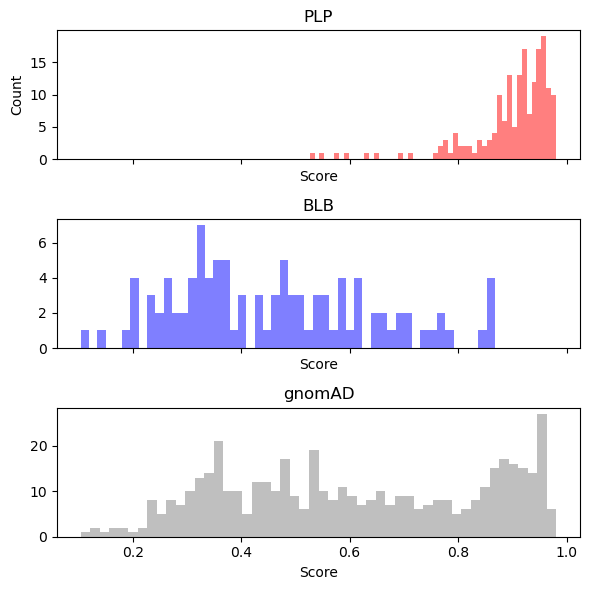

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_group_histograms(scoreset, bins=50):
    scores = scoreset.scores
    assignments = scoreset.sample_assignments  # shape (N, 3)

    group_vals = []
    
    for i in range(3):
        col = assignments[:, i]

        # handle boolean mask vs index array
        if col.dtype == bool:
            vals = scores[col]
        else:
            col = col[~np.isnan(col)].astype(int)
            col = col[col >= 0]
            vals = scores[col]

        group_vals.append(vals)

    labels = ['PLP', 'BLB', 'gnomAD']
    colors = ['red', 'blue', 'grey']

    fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

    for i, ax in enumerate(axes):
        ax.hist(group_vals[i], bins=bins, color=colors[i], alpha=0.5)
        ax.set_title(labels[i])
        ax.set_xlabel('Score')

    axes[0].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

plot_group_histograms(scoreset)

In [27]:
import gzip, json

with gzip.open(f'/data/ross/assay_calibration/predictor_scores/sg_predictor_results_1000bootstraps_100fits.json.gz', 'rt', encoding='utf-8') as f:
    results = json.load(f)

In [28]:
results["AM_F9"]['0']

{'2c': {'dataset_name': 'AM_F9',
  'bootstrap_seed': 0,
  'num_components': 2,
  'fit_idx': 2,
  'fit': {'component_params': [[1.8565281206756936,
     0.052997859911087714,
     0.11758663703422964],
    [-8.023037684241356, 1.013751015225278, 0.26003619026228664]],
   'weights': [[0.15640424634852482, 0.8435957536514751],
    [1.0, 1.199187654306514e-237],
    [0.9350995657397438, 0.06490043426025616]],
   'kmeans': 'method_of_moments',
   'xlims': [0.0452, 0.9968],
   'times_submerged': [],
   'initial_params': [[1, 0.04803612755852765, 0.3405842762941326],
    [-1, 0.953920052392761, 0.3405842762941326]],
   'latent_q': 2},
  'val_ll': 0.5145630130628502,
  'calibrated_dims': None},
 '3c': {'dataset_name': 'AM_F9',
  'bootstrap_seed': 0,
  'num_components': 3,
  'fit_idx': 78,
  'fit': {'component_params': [[1.6436523355216714,
     0.054393519016841356,
     0.08411510153845192],
    [0.7624689096749576, 0.40676995803835114, 0.18234304694238251],
    [-4.190159062897227, 1.0101463

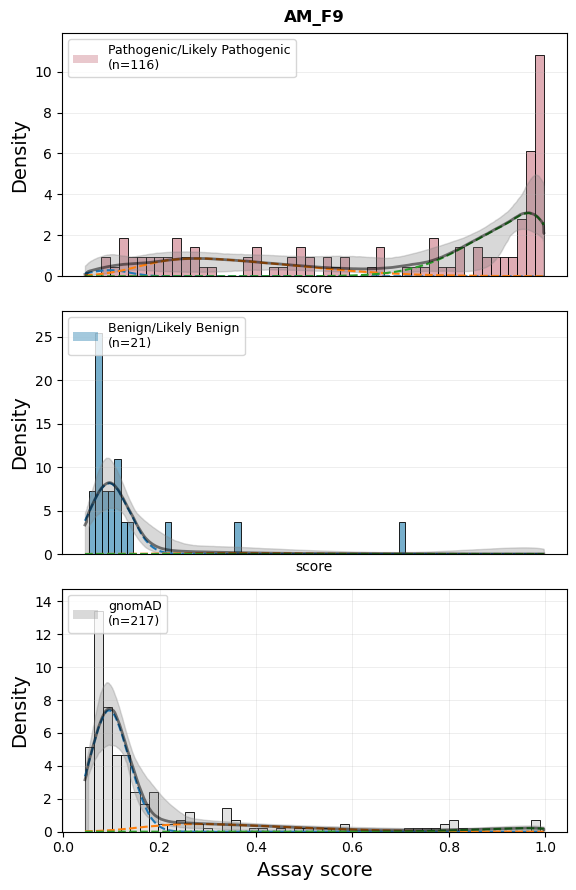

In [36]:
from src.assay_calibration.plot_utils.utils import sample_density
import scipy.stats as sps
import seaborn as sns
from matplotlib.patches import Patch
import gzip, json
import numpy as np
import pandas as pd
import sys
sys.path.append('..')
import importlib
import src.assay_calibration.data_utils.dataset
importlib.reload(src.assay_calibration.data_utils.dataset)
from src.assay_calibration.data_utils.dataset import BasicScoreset

dataset = "AM_F9"

df = pd.read_csv("/data/ross/assay_calibration/predictor_scores/concatenated_predictor_scores.csv.gz")
revel_df = df[df.Dataset == dataset]
scoreset = BasicScoreset(revel_df["score"], revel_df["sample_assignments"])

with gzip.open(f'/data/ross/assay_calibration/predictor_scores/sg_predictor_results_1000bootstraps_100fits.json.gz', 'rt', encoding='utf-8') as f:
    results = json.load(f)

# Sample colors matching the original plot
sample_colors = ['#CA7682', '#1D7AAB', '#A0A0A0', '#6BAA75']  # P/LP, B/LB, gnomAD, Synonymous
sample_alphas = [0.6, 0.6, 0.3, 0.5]
n_samples = 3
n_c = "3c"

# Create figure with n_samples rows
scale = 3
fig, axes = plt.subplots(n_samples, 1, figsize=(2*scale, scale*n_samples), squeeze=False)
axes = axes.flatten()

# Plot each sample in its own subplot
num_skipped = 0
for sample_num in range(len(scoreset.sample_counts)):
    if scoreset.sample_counts[sample_num] == 0:
        num_skipped += 1
        continue
    ax = axes[sample_num-num_skipped]
    sample_mask = scoreset.sample_assignments[:, sample_num-num_skipped]
    sample_name = scoreset.sample_names[sample_num]
    
    # Plot histogram for this sample
    sns.histplot(scoreset.scores[sample_mask], 
                 stat='density', ax=ax, 
                 alpha=sample_alphas[sample_num], 
                 color=sample_colors[sample_num],
                 bins=50)
                 # label=sample_name)
    
    max_hist_density = max([patch.get_height() for patch in ax.patches]) if ax.patches else 1.0
    score_range = np.linspace(*np.percentile(scoreset.scores,[0,100]),10000)
    fits = [results[dataset][key][n_c] for key,val in results[dataset].items()]
    
    # Plot fitted density curves with matching color
    density_sample = sample_density(score_range, fits, sample_num-num_skipped)

    for compNum in range(density_sample.shape[1]):
        compDensity = density_sample[:,compNum,:]
        d = np.nanpercentile(compDensity,[5,50,95],axis=0)
        ax.plot(score_range, d[1], color=f"C{compNum}", linestyle='--', label=f"Comp {compNum+1}")
    
    # Plot sum of components
    d = np.nansum(density_sample, axis=1)
    d_perc = np.percentile(d, [5, 50, 95], axis=0)
    ax.plot(score_range, d_perc[1], 
           color='black', 
           alpha=0.5,
           linewidth=2)
    ax.fill_between(score_range, d_perc[0], d_perc[2], 
                   color='gray', 
                   alpha=0.3)
    

    if sample_num - num_skipped == 0:
        ax.set_title(dataset, fontsize=12, fontweight='bold', pad=8)
    
    last_sample = False
    if sample_num == len(scoreset.sample_counts)-1 or (sample_num == len(scoreset.sample_counts)-2 and scoreset.sample_counts[-1] == 0):
        last_sample = True

    if last_sample:
        ax.set_xlabel("Assay score", fontsize=14)
    else:
        ax.set_xticks([])
    
    ax.set_ylabel("Density", fontsize=14)
    ax.set_ylim([0, max_hist_density * 1.1])
    # ax.legend(fontsize=11, loc='best', ncol=1, handles=handles)

    n_count = sample_mask.sum()

    
    # Create histogram legend handle
    hist_patch = Patch(
        facecolor=sample_colors[sample_num],
        alpha=0.4,
        edgecolor='none'
    )
    
    # if sample_name == "gnomAD":
    #     hist_label = f'{sample_name}\n(n={n_count:,d}, prior={indv_summary["prior"]:.3f})'
    # else:
    hist_label = f'{sample_name}\n(n={n_count:,d})'
    
    # Create histogram legend on the left
    hist_legend = ax.legend(
        [hist_patch],
        [hist_label],
        loc='upper left',
        fontsize=9,
        framealpha=0.8
    )
    
    ax.grid(linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()